In [518]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report
import warnings
from lightgbm import LGBMClassifier
import joblib
import json
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

In [519]:
df = pd.read_csv("data/cardio_train.csv", sep=";")
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [520]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [521]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [522]:
df.cardio.value_counts()

cardio
0    35021
1    34979
Name: count, dtype: int64

<Axes: >

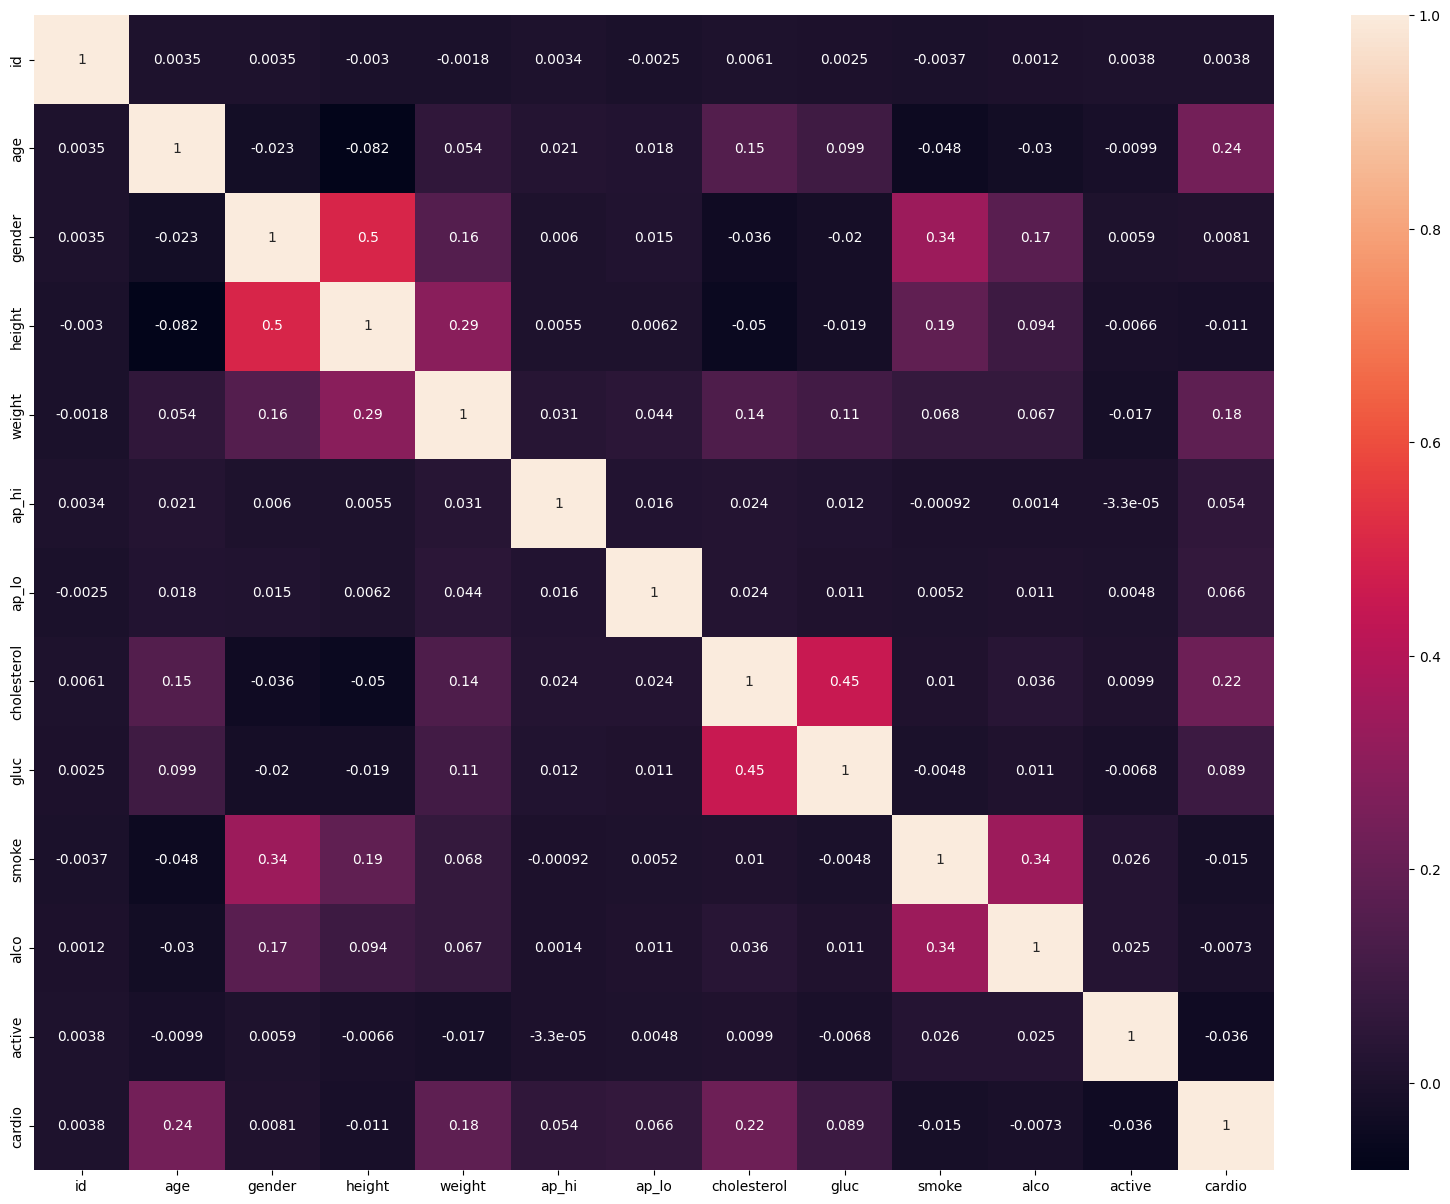

In [523]:
plt.subplots(figsize=(20, 15))
sns.heatmap(df.corr(), annot=True)

In [524]:
cleaned_df = df[df["ap_hi"] < 250]
cleaned_df = cleaned_df[cleaned_df["ap_lo"] < 250]

print(cleaned_df.shape)

(69007, 13)


In [525]:
cont_cols = ["age", "height", "weight", "ap_hi", "ap_lo"]
ord_cols = ["cholesterol", "gluc"]
bin_cols = ["gender", "smoke", "alco", "active", "cardio"]

df_normalized = cleaned_df[cont_cols].copy()

df_normalized.head()

,age,height,weight,ap_hi,ap_lo
0,18393,168,62.0,110,80
1,20228,156,85.0,140,90
2,18857,165,64.0,130,70
3,17623,169,82.0,150,100
4,17474,156,56.0,100,60


In [526]:
for col in ord_cols:
    dummies = pd.get_dummies(cleaned_df[col])
    min_ind = min([ind for ind in dummies.columns])
    dummies.columns = ["{0}_{1}".format(col, ind) for ind in dummies.columns]
    df_normalized = pd.concat(
        [df_normalized, dummies.drop(["{0}_{1}".format(col, min_ind)], axis=1)], axis=1
    )


df_normalized.head()

,age,height,weight,ap_hi,ap_lo,cholesterol_2,cholesterol_3,gluc_2,gluc_3
0,18393,168,62.0,110,80,False,False,False,False
1,20228,156,85.0,140,90,False,True,False,False
2,18857,165,64.0,130,70,False,True,False,False
3,17623,169,82.0,150,100,False,False,False,False
4,17474,156,56.0,100,60,False,False,False,False


In [527]:
df_normalized = pd.concat([df_normalized, cleaned_df[bin_cols]], axis=1)
df_normalized["gender"] -= 1

df_normalized.head()

,age,height,weight,ap_hi,ap_lo,cholesterol_2,cholesterol_3,gluc_2,gluc_3,gender,smoke,alco,active,cardio
0,18393,168,62.0,110,80,False,False,False,False,1,0,0,1,0
1,20228,156,85.0,140,90,False,True,False,False,0,0,0,1,1
2,18857,165,64.0,130,70,False,True,False,False,0,0,0,0,1
3,17623,169,82.0,150,100,False,False,False,False,1,0,0,1,1
4,17474,156,56.0,100,60,False,False,False,False,0,0,0,0,0


In [528]:
df_normalized = df_normalized.dropna()
print(df_normalized.shape)
X = df_normalized.drop("cardio", axis=1)
y = df_normalized["cardio"]
X = X.apply(pd.to_numeric, errors="coerce").astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

(69007, 14)


In [529]:
lgbm = LGBMClassifier(
    random_state=42,
    class_weight="balanced",
    n_estimators=300,
    learning_rate=0.03,
    max_depth=8,
    num_leaves=70,
)

In [530]:
lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 27258, number of negative: 27947
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002094 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 669
[LightGBM] [Info] Number of data points in the train set: 55205, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

,boosting_type,'gbdt'
,num_leaves,70
,max_depth,8
,learning_rate,0.03
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [531]:
y_pred = lgbm.predict_proba(X_test)[:, 1]
threshold = 0.45
y_pred_adj = (y_pred >= threshold).astype(int)

print("Model Accuracy: ", accuracy_score(y_test, y_pred_adj))
print(classification_report(y_test, y_pred_adj))

Model Accuracy:  0.7306187509056659
              precision    recall  f1-score   support

           0       0.74      0.72      0.73      6910
           1       0.73      0.74      0.73      6892

    accuracy                           0.73     13802
   macro avg       0.73      0.73      0.73     13802
weighted avg       0.73      0.73      0.73     13802



In [532]:
joblib.dump(lgbm, "artifacts/heart_70k_lgbm_model.pkl")
schema = {
    "features": list(X.columns),
    "dtypes": {col: str(dtype) for col, dtype in X.dtypes.items()},
    "target": "cardio",
}

with open("artifacts/heart_70k_lgbm_schema.json", "w", encoding="utf-8") as f:
    json.dump(schema, f, indent=4, ensure_ascii=False)